# Vietnam Climate Pulse: Phân tích Khám phá Khí hậu và Thời tiết Cực đoan Việt Nam

Đồ án môn học: **Trực quan hóa dữ liệu**  
Giảng viên hướng dẫn: **Thầy Bùi Tiến Lên**  
Nhóm thực hiện: **Nhóm 1**  
Danh sách thành viên:
- Lê Lâm Trí Đức -- 23120237
- Hoàng Quốc Việt -- 23120189
- Nguyễn Lê Thế Vinh -- 23120190
- Phạm Quang Vinh -- 23120202

---

## 1. Bài toán chung và Ý nghĩa thực tiễn
Việt Nam nằm trong vùng khí hậu nhiệt đới gió mùa, chịu ảnh hưởng sâu sắc của biến đổi khí hậu toàn cầu. Việc nghiên cứu các đặc trưng khí hậu và diễn biến thời tiết cực đoan như nắng nóng đỉnh điểm hay lượng mưa lịch sử có ý nghĩa sống còn đối với quản lý nông nghiệp, quy hoạch đô thị và phòng chống thiên tai.

**Bài toán chung:** Xây dựng hệ thống phân tích trực quan hóa dữ liệu khí hậu lịch sử Việt Nam giai đoạn 2020-2025, giúp khám phá các xu hướng thời tiết vĩ mô, chu kỳ mùa và mối tương quan vật lý giữa các biến đo lường thời tiết chính tại 28 trạm quan trắc trọng điểm trải dài khắp cả nước.

## 2. Các mục tiêu nhỏ phân tích trực quan để làm rõ bài toán chung
Để giải quyết và làm rõ bài toán chung trên, đồ án tập trung vào 3 mục tiêu phân tích cốt lõi:
1. **Mục tiêu 1:** Phân tích đặc trưng nhiệt độ giữa các miền (Bắc, Trung, Nam) để xác định biên độ và sự khác biệt về nền nhiệt độ vùng miền.
2. **Mục tiêu 2:** Phân tích sự dịch chuyển mùa và lượng mưa lũy tích theo tháng của các miền để tìm hiểu quy luật mùa mưa.
3. **Mục tiêu 3:** Phân tích mối liên hệ vật lý giữa bức xạ mặt trời ngắn hạn và nền nhiệt độ trung bình ngày để kiểm chứng các yếu tố năng lượng tác động lên nhiệt độ.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Thiết lập đường dẫn tương đối tới file dữ liệu processed từ notebooks/
parquet_path = "../data/processed/climate_daily.parquet"
df = pd.read_parquet(parquet_path)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

print("Kích thước bộ dữ liệu:", df.shape)
print("Các cột dữ liệu:", df.columns.tolist())
df.head()

Kích thước bộ dữ liệu: (61376, 14)
Các cột dữ liệu: ['date', 'location', 'region', 'latitude', 'longitude', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'precipitation_sum', 'rain_sum', 'wind_speed_10m_max', 'shortwave_radiation_sum', 'month', 'year']


,date,location,region,latitude,longitude,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,wind_speed_10m_max,shortwave_radiation_sum,month,year
0,2020-01-01,Bien Hoa,South,10.95,106.8167,32.3,22.2,27.1,0.0,0.0,14.3,21.09,1,2020
1,2020-01-02,Bien Hoa,South,10.95,106.8167,32.8,22.1,27.4,0.0,0.0,11.8,19.68,1,2020
2,2020-01-03,Bien Hoa,South,10.95,106.8167,32.7,22.7,27.1,0.0,0.0,11.2,19.31,1,2020
3,2020-01-04,Bien Hoa,South,10.95,106.8167,31.2,21.5,26.5,0.0,0.0,8.8,17.63,1,2020
4,2020-01-05,Bien Hoa,South,10.95,106.8167,31.4,21.0,25.6,0.0,0.0,11.1,21.49,1,2020


## 3. Thực nghiệm và Trực quan hóa chi tiết

### Mục tiêu 1: Đặc trưng nhiệt độ giữa các miền (North, Central, South)
Chúng ta sử dụng biểu đồ hộp (Boxplot) để trực quan hóa toàn diện phân bố nhiệt độ trung bình ngày của 3 miền trong suốt 6 năm (2020-2025). Biểu đồ này giúp chỉ ra trung vị, tứ phân vị, biên độ nhiệt và các điểm dị thường nhiệt độ cao/thấp.

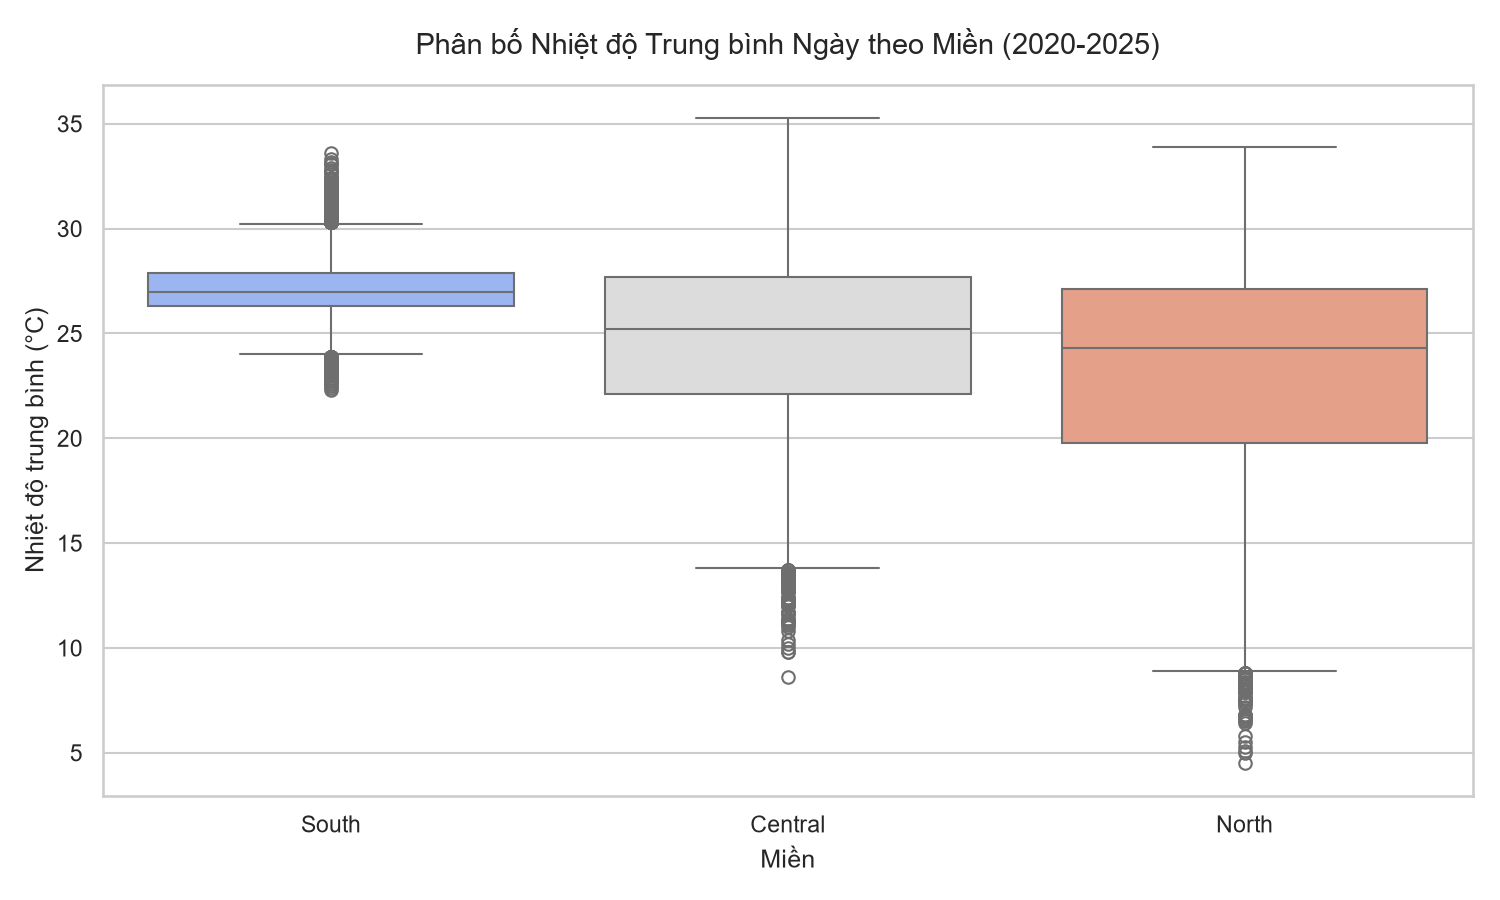

In [2]:
# Cấu hình thẩm mỹ cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='region', y='temperature_2m_mean', palette='coolwarm')
plt.title('Phân bố Nhiệt độ Trung bình Ngày theo Miền (2020-2025)', fontsize=14, pad=15)
plt.xlabel('Miền', fontsize=12)
plt.ylabel('Nhiệt độ trung bình (°C)', fontsize=12)
plt.tight_layout()
plt.show()

**Nhận xét:** Miền Nam có nền nhiệt độ trung bình ngày rất cao và ổn định (dao động nhỏ xung quanh 27-28 độ C), miền Bắc có biên độ biến động nhiệt độ rộng nhất với mùa đông lạnh xuống dưới 10 độ C và mùa hè nóng trên 35 độ C, trong khi miền Trung mang tính chất trung gian nhưng có các ngày nắng nóng cực đoan đạt nhiệt độ rất cao.

---

### Mục tiêu 2: Sự dịch chuyển mùa mưa của các miền
Chúng ta sử dụng biểu đồ đường chuỗi thời gian (Line plot) gom nhóm theo tháng và miền để so sánh xu hướng lượng mưa ngày trung bình. Biểu đồ chỉ ra sự lệch pha về đỉnh mùa mưa giữa các vùng địa lý của Việt Nam.

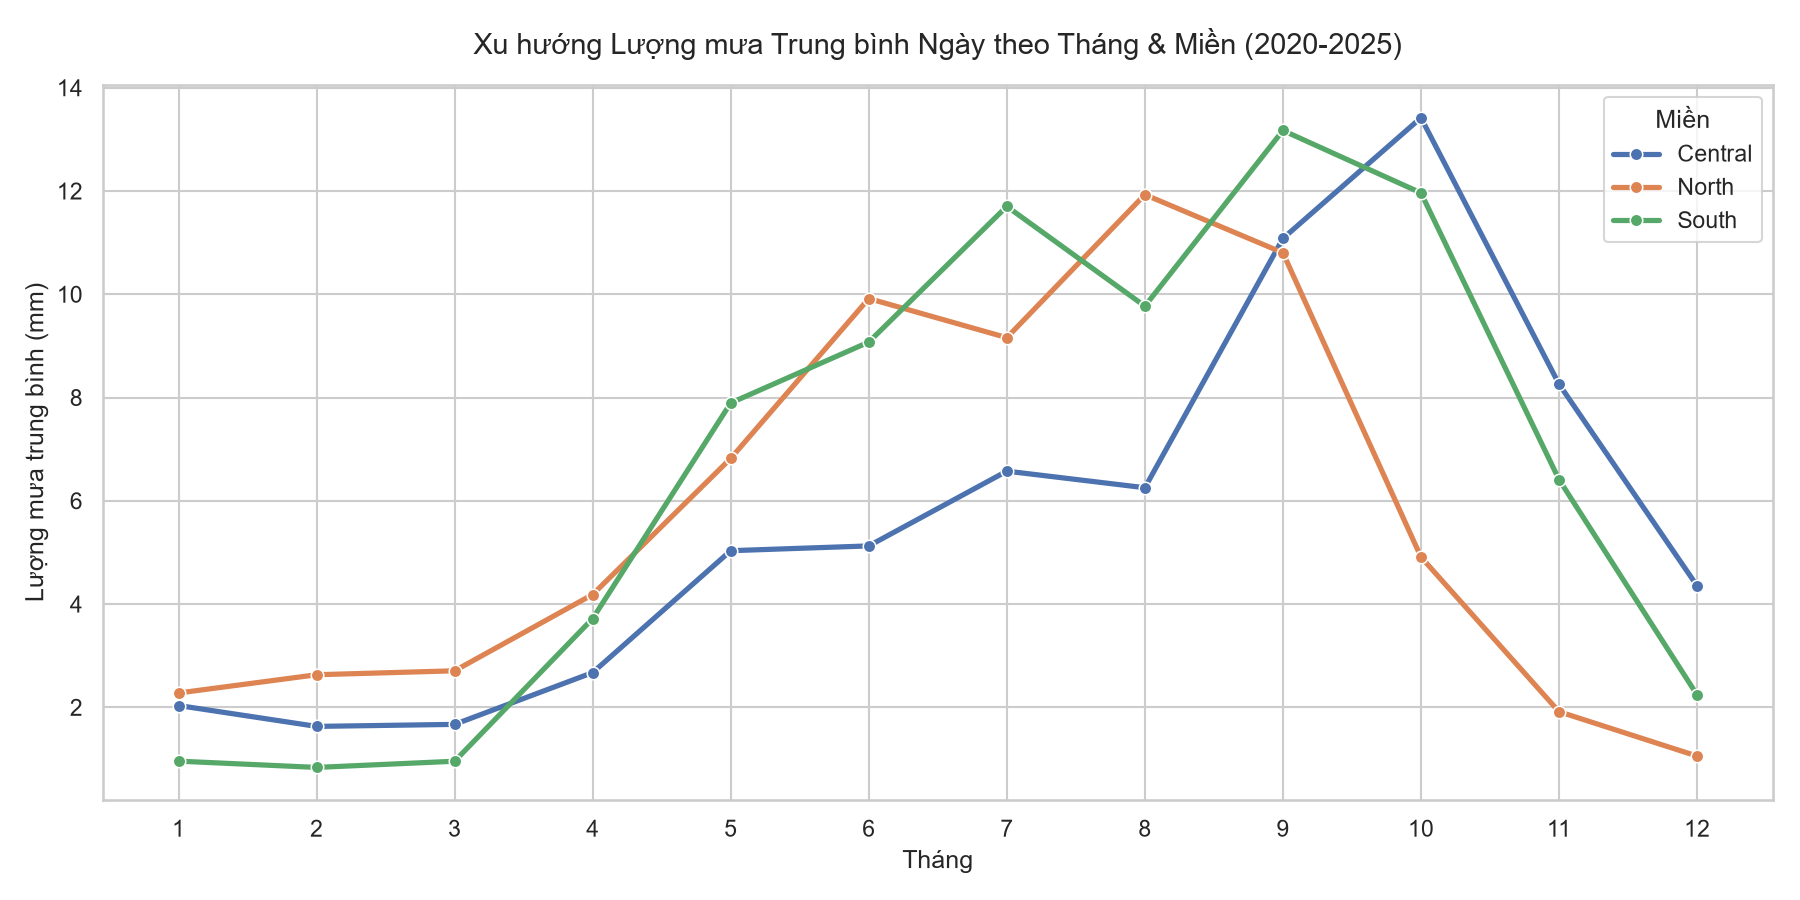

In [3]:
# Tính lượng mưa trung bình ngày theo tháng và miền
monthly_rain = df.groupby(['region', 'month'])['precipitation_sum'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_rain, x='month', y='precipitation_sum', hue='region', marker='o', linewidth=2.5)
plt.title('Xu hướng Lượng mưa Trung bình Ngày theo Tháng & Miền (2020-2025)', fontsize=14, pad=15)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Lượng mưa trung bình (mm)', fontsize=12)
plt.xticks(range(1, 13))
plt.legend(title='Miền')
plt.tight_layout()
plt.show()

**Nhận xét:** Miền Bắc và miền Nam có chu kỳ mùa mưa đồng pha, bắt đầu tăng mạnh từ tháng 5, đạt đỉnh vào tháng 8 (ở miền Bắc) và tháng 9 (ở miền Nam) trước khi giảm dần vào mùa khô đông. Trái lại, miền Trung thể hiện sự dịch chuyển mùa mưa rõ nét khi mùa mưa đến muộn và tập trung cực kỳ khốc liệt từ tháng 9 đến tháng 11, với lượng mưa trung bình ngày vượt trội hẳn các miền khác.

---

### Mục tiêu 3: Mối quan hệ giữa bức xạ mặt trời ngắn hạn và nhiệt độ
Chúng ta sử dụng biểu đồ phân tán (Scatter Plot) để khảo sát trực quan mối tương quan giữa tổng lượng bức xạ sóng ngắn tích lũy ngày (`shortwave_radiation_sum`) và nhiệt độ trung bình ngày (`temperature_2m_mean`).

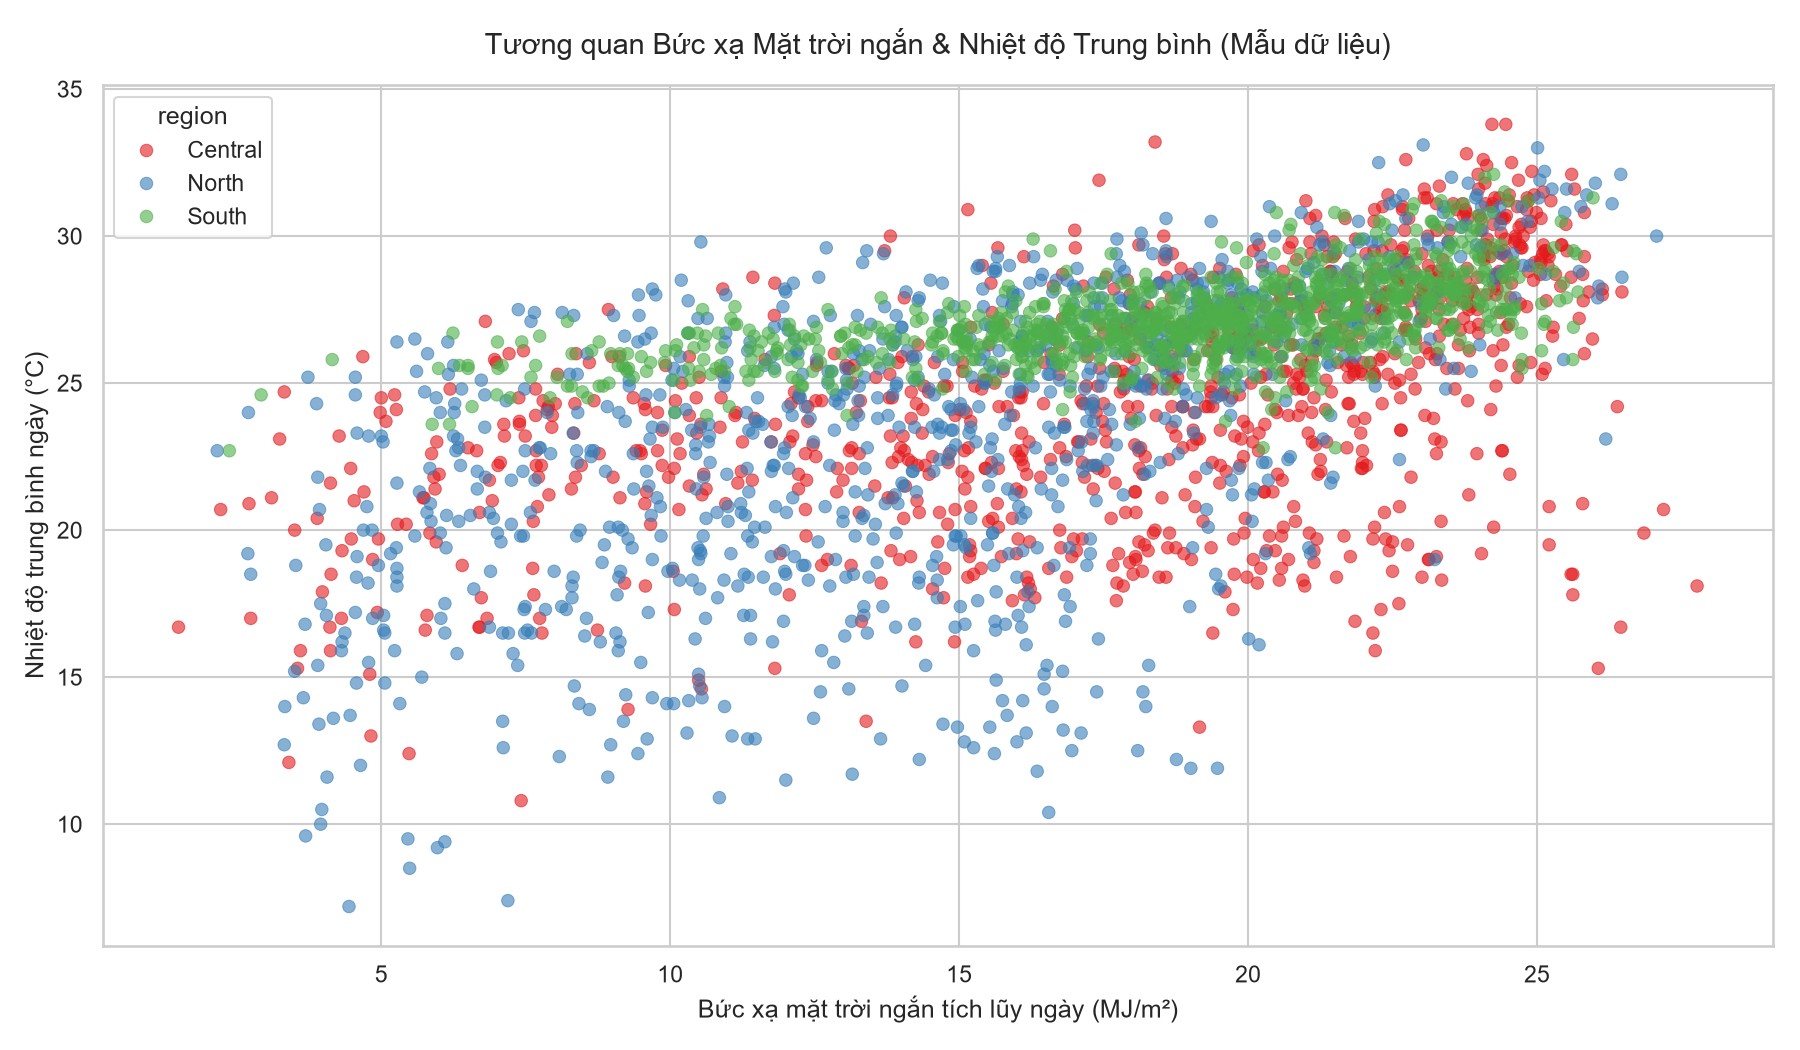

In [4]:
# Lấy mẫu 1000 dòng mỗi miền để hiển thị rõ các phân bố điểm mà không bị chồng lấp quá mức
df_sample = df.groupby('region').apply(lambda x: x.sample(n=min(1000, len(x)), random_state=42)).reset_index(drop=True)

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_sample, 
    x='shortwave_radiation_sum', 
    y='temperature_2m_mean', 
    hue='region', 
    alpha=0.6,
    palette='Set1',
    edgecolor=None
)
plt.title('Tương quan Bức xạ Mặt trời ngắn & Nhiệt độ Trung bình (Mẫu dữ liệu)', fontsize=14, pad=15)
plt.xlabel('Bức xạ mặt trời ngắn tích lũy ngày (MJ/m²)', fontsize=12)
plt.ylabel('Nhiệt độ trung bình ngày (°C)', fontsize=12)
plt.tight_layout()
plt.show()

**Nhận xét:** Hệ số tương quan Pearson dương thể hiện mối quan quan đồng biến mạnh mẽ. Lượng bức xạ sóng ngắn từ mặt trời càng tích lũy nhiều thì nhiệt độ không khí ngày càng cao. Phân cụm các màu sắc cũng thể hiện rõ đặc tính vùng miền: Miền Nam (màu xanh lá đại diện) tập trung chủ yếu ở góc trên bên phải (bức xạ cao quanh năm, nhiệt độ cao quanh năm); Miền Bắc (màu đỏ) có phân bố trải rộng từ góc dưới bên trái (bức xạ thấp và lạnh vào mùa đông) tới góc trên bên phải (bức xạ cao và nóng vào mùa hè).